# 1. Project Introduction

Welcome! In this notebook, we will explore **K-Means Clustering**, one of the most popular unsupervised learning algorithms.

### What is K-Means?
* It is an **unsupervised learning** clustering algorithm.
* Unsupervised means the dataset does **not have target labels** (y). The algorithm must discover patterns and group data on its own.
* It groups data points into $K$ distinct clusters based on feature similarity (distance).
* **Centroid**: The center point of a cluster. K-Means moves centroids iteratively until it finds the optimal groups.

### Why does it exist?
* It helps us segment and discover natural groupings in datasets.

### Real-World Use Cases:
* **Flower Sample Segmentation**: Grouping buyers based on petal width and petal length.
* **Document Clustering**: Organizing documents by content topics.


# 2. Problem Statement

* **Goal**: Group retail store flower samples into flower sample segments based on their petal length and petal width.
* **Business Value**: Enables marketers to target specific flower sample clusters with custom-tailored promotions.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# 4. Create Synthetic Dataset

We define petal length and petal width behaviors for **100 flower samples**.
* **Petal_Length**: Annual petal length in k$.
* **Petal_Width**: Store rating of flower sample petal width frequency and size (1 to 100).
* Note: There are **no labels** in this dataset!


In [2]:
# Load scikit-learn iris dataset
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris(as_frame=True)
raw_df = iris.frame

df = pd.DataFrame({
    'Petal_Length': raw_df['petal length (cm)'],
    'Petal_Width': raw_df['petal width (cm)']
})

print("Shape:", df.shape)
print(df.head())


Shape: (150, 2)
   Petal_Length  Petal_Width
0           1.4          0.2
1           1.4          0.2
2           1.3          0.2
3           1.5          0.2
4           1.4          0.2


# 5. Exploratory Data Analysis (EDA)


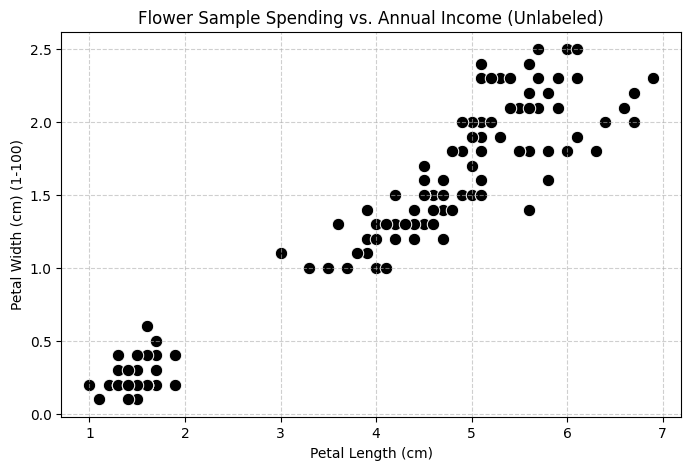

In [3]:
# Chart 1: Raw Income vs Petal Width (cm)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Petal_Length', y='Petal_Width', data=df, color='black', s=80)
plt.title('Flower Sample Spending vs. Annual Income (Unlabeled)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm) (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* The flower samples appear to cluster naturally into three or four distinct regions.


In [4]:
# Cleaning check
print("Null count:", df.isnull().sum().sum())


Null count: 0


# 7. Feature Selection

Since clustering is unsupervised, we select our descriptive features as `X`. There is no target `y`.


In [5]:
# Select descriptive columns
X = df[['Petal_Length', 'Petal_Width']]


# 8. Train-Test Split

* Unsupervised algorithms are usually trained on the whole dataset to find patterns, so we do not split the data here.


# 9. Model Building

* **How it works conceptually**: It places $K$ centroids randomly. Then, it repeats two steps:
  1. **Assign**: Assigns each point to its closest centroid.
  2. **Update**: Recalculates the center of each cluster and moves the centroid there.
* We set $K=3$ for our initial segmentation.


In [6]:
# Initialize K-Means with 3 clusters
model = KMeans(n_clusters=3, random_state=42)


In [7]:
# Fit model
model.fit(X)
print("K-Means training completed successfully!")


K-Means training completed successfully!


In [8]:
# Get cluster assignments
labels = model.labels_

# View assignments for first few flower samples
print("First 10 cluster assignments:", labels[:10])


First 10 cluster assignments: [1 1 1 1 1 1 1 1 1 1]


# 12. Evaluation

Unsupervised models do not have true labels to verify accuracy, so we use:
* **Inertia**: Sum of squared distances of samples to their closest cluster center. Lower is better.
* **Silhouette Score**: Measures how close a point is to its own cluster compared to other clusters (ranges from -1 to +1). Higher is better.


In [9]:
# Compute cluster evaluations
inertia = model.inertia_
silhouette = silhouette_score(X, labels)

print(f"Inertia Score: {inertia:.4f}")
print(f"Silhouette Score: {silhouette:.4f} (Closer to 1 means clean separation)")


Inertia Score: 31.3714
Silhouette Score: 0.6605 (Closer to 1 means clean separation)


### How to Interpret These Metrics:
* **Inertia Score**:
  * **Definition**: The sum of squared distances of samples to their closest cluster center. It measures how internally coherent clusters are.
  * **Interpretation**: Lower inertia means tighter clusters. However, inertia naturally decreases as we increase K (number of clusters), which is why we use the Elbow Method to find the optimal point.
* **Silhouette Score**:
  * **Definition**: Measures how similar an object is to its own cluster compared to other clusters. It ranges from -1 to +1.
  * **Interpretation**: A score closer to **+1** (e.g. 0.50 to 0.70) indicates that the samples are well clustered and there is clear separation between the clusters. A score close to 0 means overlapping clusters.


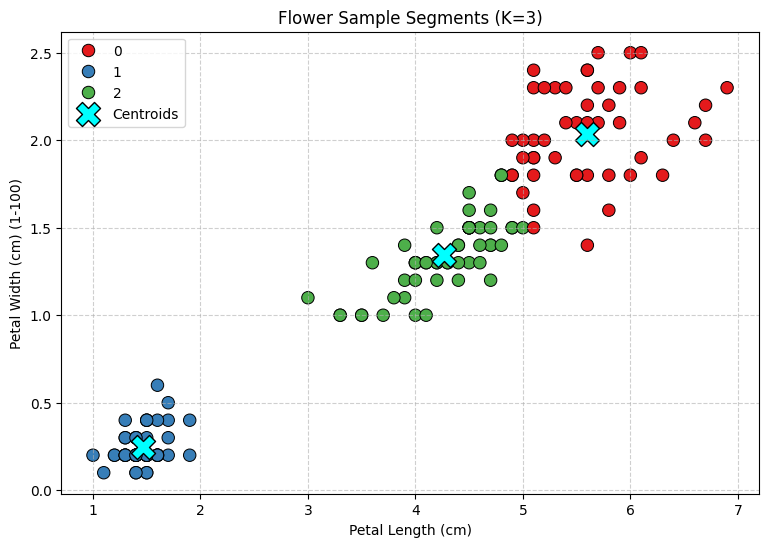

In [10]:
# Plot 1: Cluster Assignments and Centroids
centroids = model.cluster_centers_

plt.figure(figsize=(9, 6))
sns.scatterplot(x='Petal_Length', y='Petal_Width', hue=labels, palette='Set1', data=df, s=80, edgecolor='black')
# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], color='cyan', marker='X', s=300, edgecolor='black', label='Centroids')
plt.title('Flower Sample Segments (K=3)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm) (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


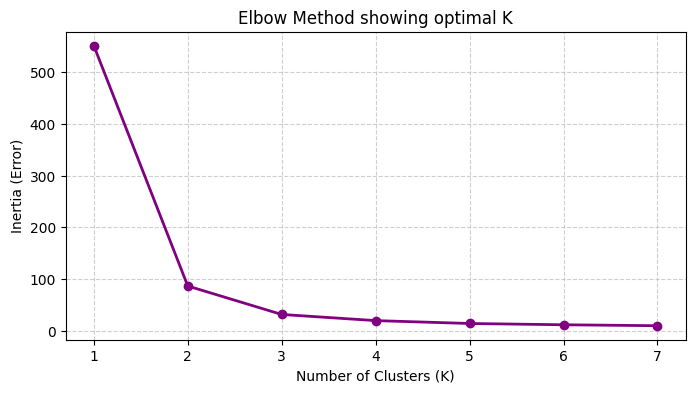

In [11]:
# Plot 2: Elbow Curve
inertia_values = []
k_range = range(1, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia_values, marker='o', color='purple', linewidth=2)
plt.title('Elbow Method showing optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Error)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* At $K=3$, the clusters are clearly separated.
* The Elbow plot shows a sharp bend or "elbow" at $K=3$, confirming it is the optimal choice.


In [12]:
# Check cluster centers
print("Centroid Coordinates (Petal Length, Petal Width):")
for i, centroid in enumerate(centroids):
    print(f"* Cluster {i}: Petal Length = {centroid[0]:.2f}k$, Petal Width (cm) = {centroid[1]:.2f}")


Centroid Coordinates (Petal Length, Petal Width):
* Cluster 0: Petal Length = 5.60k$, Petal Width (cm) = 2.04
* Cluster 1: Petal Length = 1.46k$, Petal Width (cm) = 0.25
* Cluster 2: Petal Length = 4.27k$, Petal Width (cm) = 1.34


# 15. Conclusion
* We grouped flower samples into 3 distinct petal width segments.
* Centroids help marketers understand and target each group's behaviors.


# 16. Beginner ML Dictionary

Here are simple, one-sentence explanations of common Machine Learning terms to help you review:

* **Feature**: An input variable or column in your dataset used to make predictions (e.g., hours studied).
* **Target**: The output variable or label you want the model to predict (e.g., final exam score).
* **Training Data**: The portion of the dataset used to teach the model and find patterns.
* **Testing Data**: The portion of the dataset held back to evaluate how well the model performs on new, unseen data.
* **Prediction**: The output value generated by the trained model when given new input features.
* **Overfitting**: A scenario where the model learns the training data too well, including its noise, and performs poorly on new data.
* **Underfitting**: A scenario where the model is too simple to learn the underlying patterns in the training data, leading to poor performance on both training and test data.
* **Model**: The mathematical representation of the patterns learned from the training data by the algorithm.
* **Algorithm**: The set of rules or mathematical procedures followed to build the model from the data (e.g., Linear Regression).
* **Accuracy**: The percentage of correct predictions made by a classification model.
* **Cluster**: A group of similar data points grouped together by an unsupervised learning algorithm based on their characteristics.
* **Centroid**: The center point of a cluster, representing the average location of all data points belonging to that cluster.
